In [ ]:
import subprocess
subprocess.run([
    "pip", "install", "-q",
    "captum",
    "numpy==1.26.4",  # pin to version compatible with torch on Colab
], check=True)
print("✅ Done. Now RESTART RUNTIME, then run Cell 2.")

✅ Done. Now RESTART RUNTIME, then run Cell 2.


In [1]:
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from captum.attr import LayerIntegratedGradients
from IPython.display import display, HTML
from google.colab import drive
drive.mount('/content/drive')

print("Libraries loaded.")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️  No GPU")

Mounted at /content/drive
Libraries loaded.
GPU: Tesla T4


In [2]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────────────
DATA_DIR       = "/content/drive/MyDrive/disaster_project/disaster_data"
MODELS_DIR     = "/content/drive/MyDrive/disaster_project/disaster_models"
ENSEMBLE_DIR   = "/content/drive/MyDrive/disaster_project/ensemble_results"
CONFIDENCE_DIR = "/content/drive/MyDrive/disaster_project/confidence_results"
EXPLAIN_DIR    = "/content/drive/MyDrive/disaster_project/explainability_results"
os.makedirs(EXPLAIN_DIR, exist_ok=True)

# We use RoBERTa as the explainer model — best single model
EXPLAINER_MODEL_PATH = f"{MODELS_DIR}/roberta/best_model"


In [3]:
# ── Cell 3: Load Label Mapping ────────────────────────────────────────────────
with open(f"{DATA_DIR}/label_mapping.json") as f:
    mapping = json.load(f)

label2id    = mapping["label2id"]
id2label    = {int(k): v for k, v in mapping["id2label"].items()}
NUM_LABELS  = len(label2id)
CLASS_NAMES = [id2label[i] for i in range(NUM_LABELS)]

print(f"Labels loaded: {NUM_LABELS} classes")


Labels loaded: 10 classes


In [4]:
# ── Cell 4: Load RoBERTa Model & Tokenizer ───────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(EXPLAINER_MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(
    EXPLAINER_MODEL_PATH,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)
model.eval()
print(f"RoBERTa loaded on {device}")


Loading weights:   0%|          | 0/201 [00:02<?, ?it/s]

RoBERTa loaded on cuda


In [5]:
# ── Cell 5: Load Ensemble Predictions & Confidence Threshold ─────────────────
ensemble_data     = np.load(f"{ENSEMBLE_DIR}/ensemble_predictions.npz")
ensemble_probs    = ensemble_data["probs"]
ensemble_preds    = ensemble_data["preds"]
ensemble_labels   = ensemble_data["labels"]
optimal_threshold = float(np.load(f"{CONFIDENCE_DIR}/optimal_threshold.npy"))

print(f"Ensemble predictions loaded: {len(ensemble_preds)} samples")
print(f"Optimal confidence threshold: {optimal_threshold}")


Ensemble predictions loaded: 15160 samples
Optimal confidence threshold: 0.74


In [6]:
# ── Cell 6: Load Raw Test Tweets ──────────────────────────────────────────────
from datasets import load_dataset

raw_dataset = load_dataset(
    "parquet",
    data_files={"test": f"{DATA_DIR}/test.parquet"}
)
test_tweets = raw_dataset["test"]["tweet_text"]
test_labels_raw = raw_dataset["test"]["label"]
print(f"Raw tweets loaded: {len(test_tweets)}")


Generating test split: 0 examples [00:00, ? examples/s]

Raw tweets loaded: 15160


In [7]:
# ── Cell 7: Integrated Gradients Setup ───────────────────────────────────────
# We attribute at the embedding layer — this gives token-level importance scores
# LayerIntegratedGradients accumulates gradients from input embeddings to output

def predict_fn(input_ids, attention_mask, token_type_ids=None):
    """Forward pass returning logits for captum."""
    kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
    if token_type_ids is not None:
        kwargs["token_type_ids"] = token_type_ids
    outputs = model(**kwargs)
    return outputs.logits

# Target the word embedding layer
lig = LayerIntegratedGradients(
    lambda input_ids, attn_mask: predict_fn(input_ids, attn_mask),
    model.roberta.embeddings.word_embeddings
)

def compute_attributions(text, predicted_class, n_steps=50):
    """
    Compute Integrated Gradients attributions for a single tweet.
    Returns tokens and their attribution scores.
    """
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding="max_length",
    )

    input_ids      = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # Baseline = all padding tokens (zero embedding reference point)
    baseline_ids = torch.zeros_like(input_ids)
    baseline_ids[:, 0]  = tokenizer.cls_token_id   # keep CLS
    baseline_ids[:, -1] = tokenizer.sep_token_id   # keep SEP

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        additional_forward_args=(attention_mask,),
        target=predicted_class,
        n_steps=n_steps,
        return_convergence_delta=True,
    )

    # Sum attributions across embedding dimension, take absolute value
    attr_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()

    # Get actual tokens (excluding padding)
    tokens     = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().numpy())
    seq_len    = attention_mask.squeeze(0).sum().item()
    tokens     = tokens[:seq_len]
    attr_scores = attr_scores[:seq_len]

    # Normalise to [-1, 1]
    max_abs = np.abs(attr_scores).max()
    if max_abs > 0:
        attr_scores = attr_scores / max_abs

    return tokens, attr_scores, float(delta.abs().mean())


In [8]:
# ── Cell 8: HTML Visualisation Function ──────────────────────────────────────
def tokens_to_html(tokens, attributions, predicted_class, true_class, confidence):
    """
    Renders token attributions as colour-highlighted HTML.
    Green = positive attribution (supports prediction)
    Red   = negative attribution (opposes prediction)
    """
    def score_to_color(score):
        if score > 0:
            intensity = min(int(score * 200), 200)
            return f"rgba(0, 180, 0, {intensity/255:.2f})"
        else:
            intensity = min(int(abs(score) * 200), 200)
            return f"rgba(220, 0, 0, {intensity/255:.2f})"

    html_parts = []
    for token, score in zip(tokens, attributions):
        # Clean up RoBERTa subword tokens (Ġ = space prefix)
        display_token = token.replace("Ġ", " ").replace("Ċ", "\n")
        if token in [tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token]:
            continue
        color = score_to_color(score)
        html_parts.append(
            f'<span style="background-color:{color}; padding:2px 3px; '
            f'margin:1px; border-radius:3px; font-family:monospace; font-size:14px;" '
            f'title="attribution: {score:.3f}">{display_token}</span>'
        )

    correct = predicted_class == true_class
    label_color = "#2d8a2d" if correct else "#cc0000"
    status = "✅ Correct" if correct else "❌ Incorrect"

    html = f"""
    <div style="border:1px solid #ddd; border-radius:8px; padding:15px; margin:10px 0;
                font-family:sans-serif; background:#fafafa;">
        <div style="margin-bottom:10px;">
            <b>Predicted:</b>
            <span style="color:{label_color}; font-weight:bold;">
                {CLASS_NAMES[predicted_class]}
            </span>
            &nbsp;|&nbsp;
            <b>True:</b> {CLASS_NAMES[true_class]}
            &nbsp;|&nbsp;
            <b>Confidence:</b> {confidence:.1%}
            &nbsp;|&nbsp;
            <span style="color:{label_color}">{status}</span>
        </div>
        <div style="line-height:2.2; word-wrap:break-word;">
            {''.join(html_parts)}
        </div>
        <div style="margin-top:8px; font-size:11px; color:#888;">
            🟢 Green = supports prediction &nbsp;|&nbsp; 🔴 Red = opposes prediction
        </div>
    </div>
    """
    return html


In [9]:
# ── Cell 9: Select Representative Samples ────────────────────────────────────
# Pick 2 samples per class — one correct, one incorrect where possible
# Prioritise high-confidence samples for clean explanations

print("Selecting representative samples...")

samples_to_explain = []

for c in range(NUM_LABELS):
    class_mask  = (ensemble_labels == c)
    class_idx   = np.where(class_mask)[0]
    confidences = ensemble_probs[class_idx].max(axis=1)

    # Sort by confidence descending
    sorted_by_conf = class_idx[np.argsort(confidences)[::-1]]

    correct_added   = 0
    incorrect_added = 0

    for idx in sorted_by_conf:
        pred       = ensemble_preds[idx]
        true       = ensemble_labels[idx]
        conf       = ensemble_probs[idx].max()
        is_correct = (pred == true)

        if is_correct and correct_added < 1 and conf >= optimal_threshold:
            samples_to_explain.append({
                "idx": int(idx), "class": c,
                "correct": True, "confidence": float(conf)
            })
            correct_added += 1

        if not is_correct and incorrect_added < 1:
            samples_to_explain.append({
                "idx": int(idx), "class": c,
                "correct": False, "confidence": float(conf)
            })
            incorrect_added += 1

        if correct_added >= 1 and incorrect_added >= 1:
            break

print(f"Selected {len(samples_to_explain)} samples to explain ({NUM_LABELS} classes × 2)")


Selecting representative samples...
Selected 20 samples to explain (10 classes × 2)


In [10]:
# ── Cell 10: Compute Attributions & Display ───────────────────────────────────
print("\nComputing Integrated Gradients attributions...")
print("This may take 3–5 minutes on GPU.\n")

all_explanations = []

for i, sample in enumerate(samples_to_explain):
    idx        = sample["idx"]
    tweet      = test_tweets[idx]
    true_label = int(ensemble_labels[idx])
    pred_label = int(ensemble_preds[idx])
    confidence = sample["confidence"]

    tokens, attributions, delta = compute_attributions(tweet, pred_label)

    explanation = {
        "tweet":       tweet,
        "true_label":  CLASS_NAMES[true_label],
        "pred_label":  CLASS_NAMES[pred_label],
        "confidence":  confidence,
        "correct":     sample["correct"],
        "tokens":      tokens,
        "attributions": attributions.tolist(),
        "conv_delta":  delta,
    }
    all_explanations.append(explanation)

    # Display HTML in notebook
    html = tokens_to_html(tokens, attributions, pred_label, true_label, confidence)
    display(HTML(f"<h4>Sample {i+1} — Class: {CLASS_NAMES[sample['class']]}</h4>"))
    display(HTML(html))

    if (i + 1) % 5 == 0:
        print(f"  Processed {i+1}/{len(samples_to_explain)} samples...")

print(f"\n✅ All {len(samples_to_explain)} attributions computed.")



Computing Integrated Gradients attributions...
This may take 3–5 minutes on GPU.



  Processed 5/20 samples...


  Processed 10/20 samples...


  Processed 15/20 samples...


  Processed 20/20 samples...

✅ All 20 attributions computed.



Generating attribution summary charts...


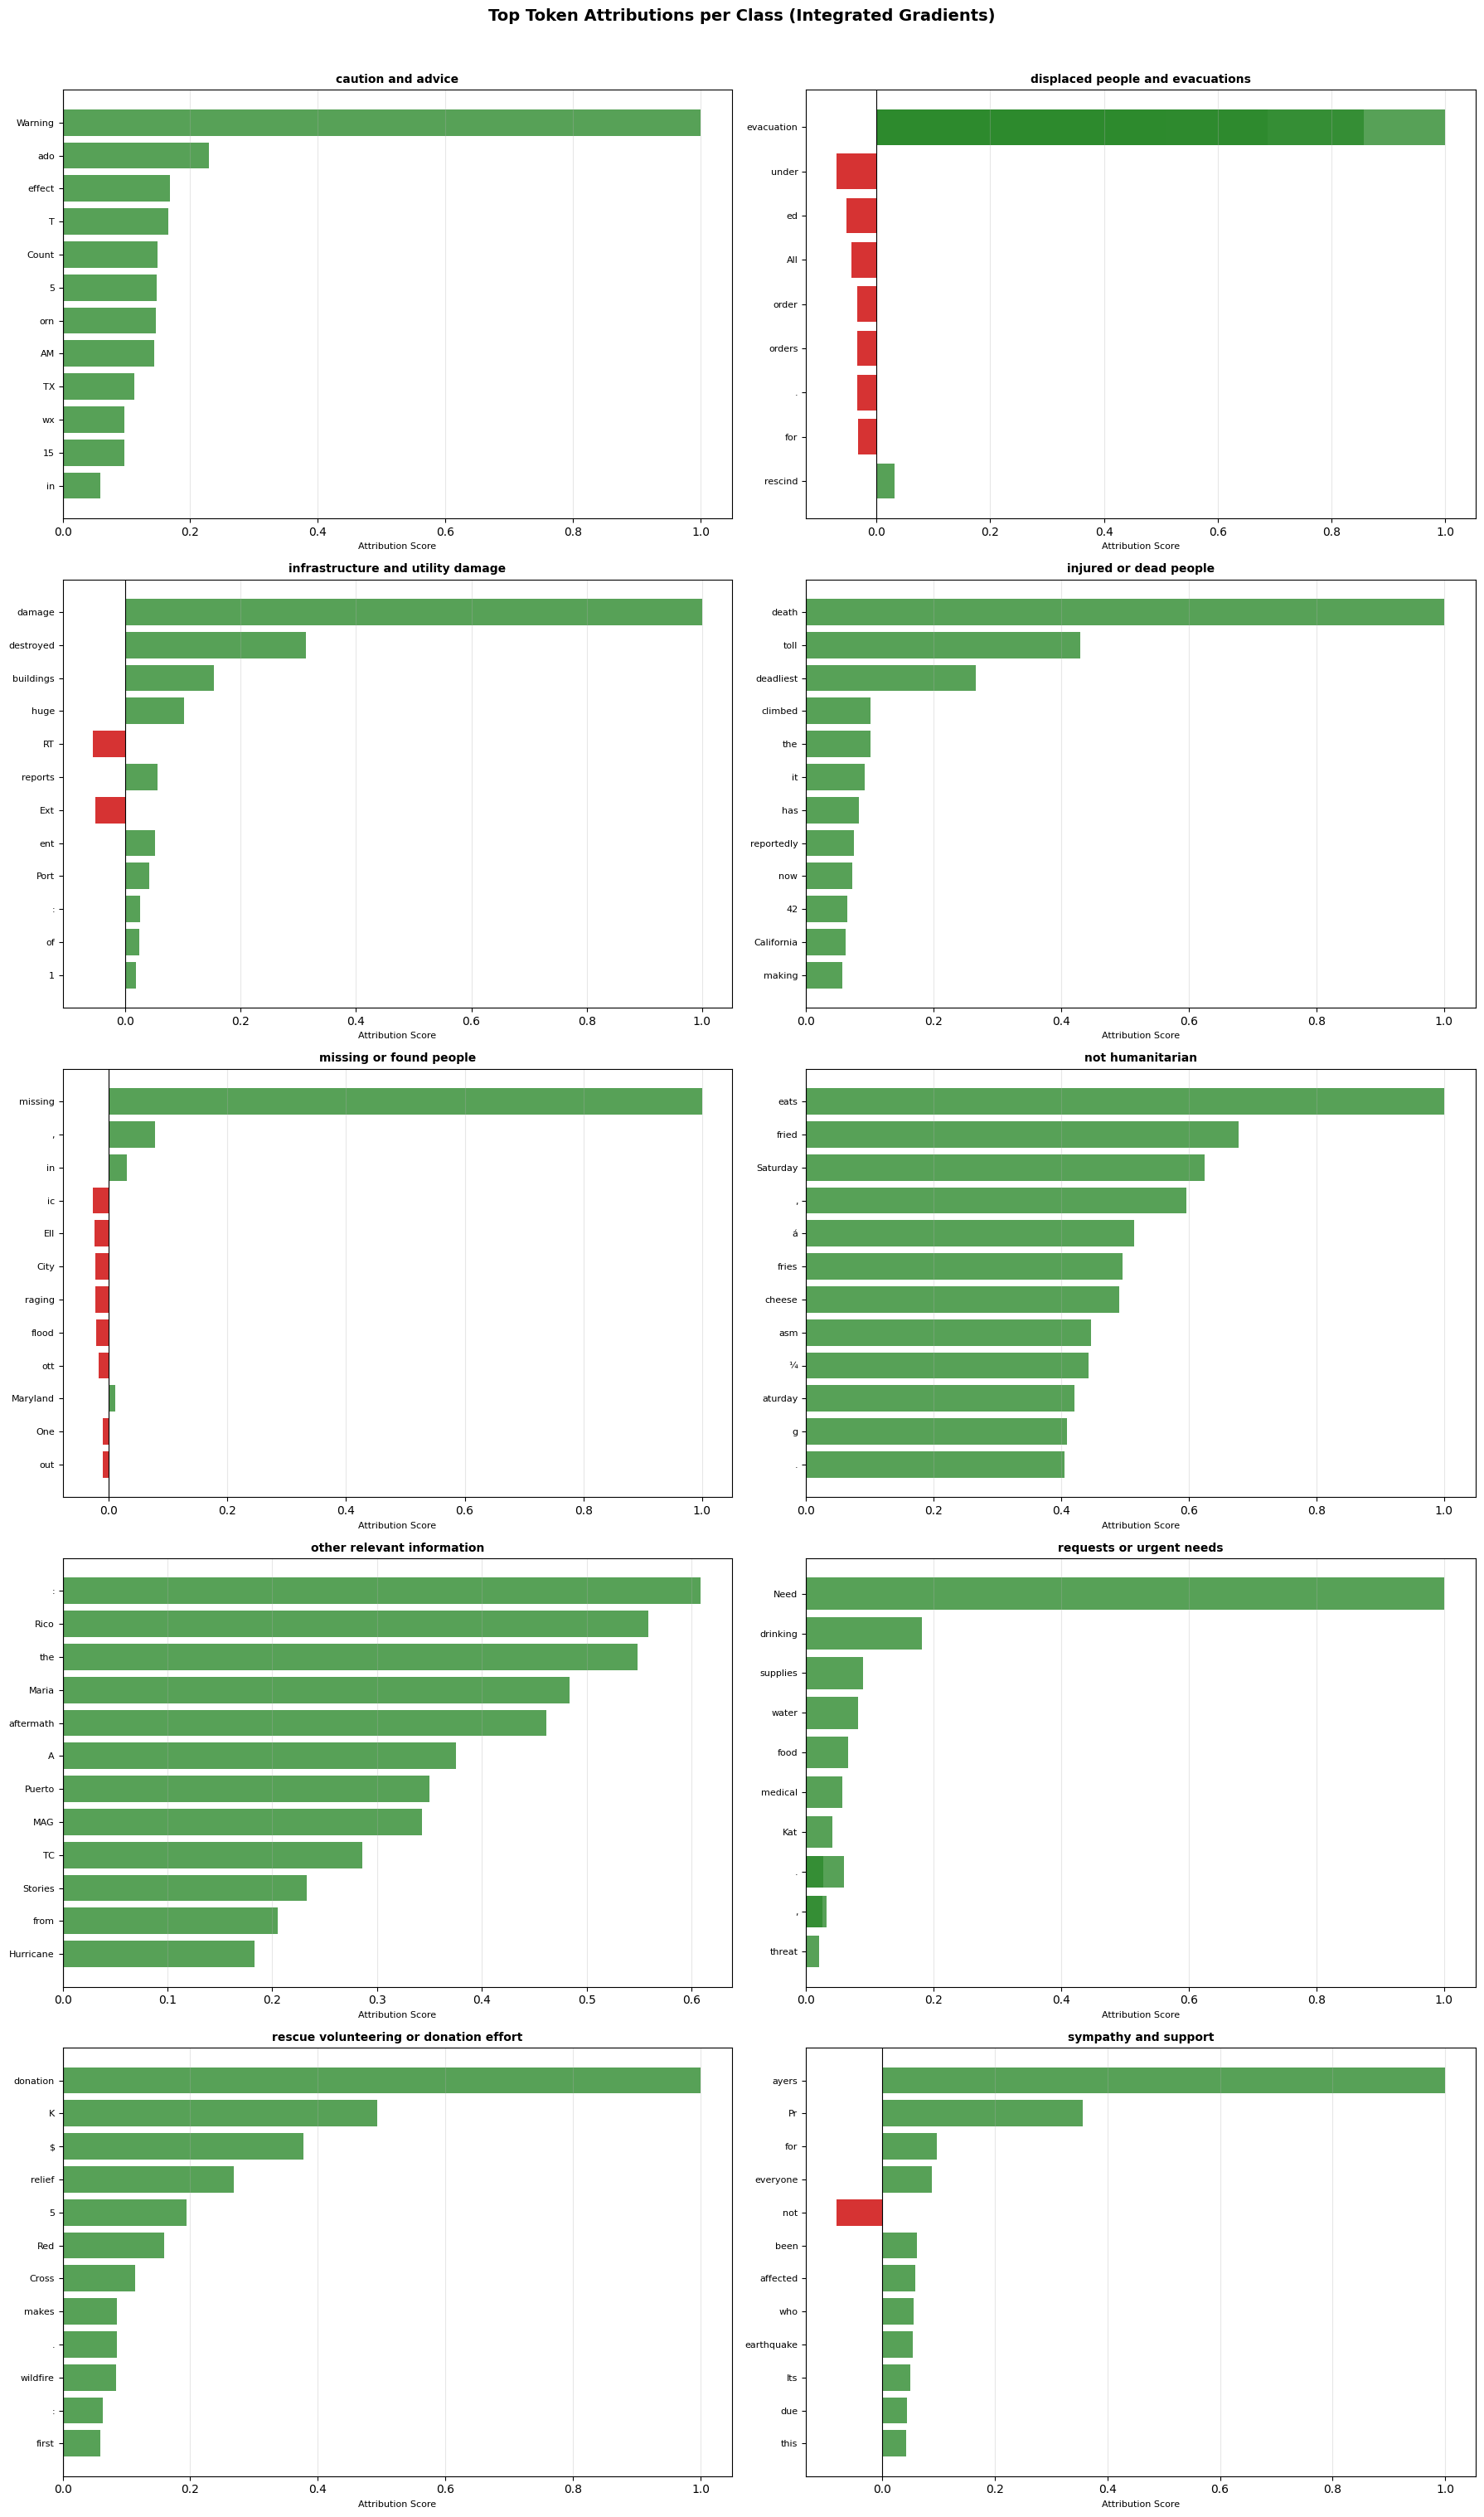

✅ Attribution summary chart saved.


In [11]:
# ── Cell 11: Attribution Summary Bar Chart (one per class) ───────────────────
print("\nGenerating attribution summary charts...")

fig, axes = plt.subplots(5, 2, figsize=(18, 30))
axes = axes.flatten()

# One chart per class — show top tokens by attribution magnitude
for c in range(NUM_LABELS):
    class_samples = [e for e in all_explanations
                     if e["pred_label"] == CLASS_NAMES[c] and e["correct"]]
    if not class_samples:
        class_samples = [e for e in all_explanations
                         if e["true_label"] == CLASS_NAMES[c]]
    if not class_samples:
        continue

    sample    = class_samples[0]
    tokens    = sample["tokens"]
    attrs     = np.array(sample["attributions"])

    # Remove special tokens
    skip = {tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token}
    filtered = [(t.replace("Ġ", ""), a) for t, a in zip(tokens, attrs) if t not in skip]
    if not filtered:
        continue

    filtered.sort(key=lambda x: abs(x[1]), reverse=True)
    top_n  = filtered[:12]
    labels = [t for t, _ in top_n]
    values = [a for _, a in top_n]
    colors = ["#2d8a2d" if v > 0 else "#cc0000" for v in values]

    ax = axes[c]
    bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(CLASS_NAMES[c].replace("_", " "), fontsize=10, fontweight="bold")
    ax.set_xlabel("Attribution Score", fontsize=8)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Top Token Attributions per Class (Integrated Gradients)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{EXPLAIN_DIR}/token_attributions_per_class.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Attribution summary chart saved.")


In [12]:
# ── Cell 12: Save Explanations ────────────────────────────────────────────────
with open(f"{EXPLAIN_DIR}/explanations.json", "w") as f:
    json.dump(all_explanations, f, indent=2)

print(f"\n✅ All explanations saved to {EXPLAIN_DIR}/explanations.json")
print("\n" + "="*55)
print("NOVELTY 3 COMPLETE")
print("="*55)
print(f"  Samples explained : {len(all_explanations)}")
print(f"  Classes covered   : {NUM_LABELS}")
print(f"  Method            : Integrated Gradients (captum)")
print(f"  Explainer model   : RoBERTa")
print("="*55)
print("\nNext step: Frontend — Interactive Disaster Tweet Classifier UI")


✅ All explanations saved to /content/drive/MyDrive/disaster_project/explainability_results/explanations.json

NOVELTY 3 COMPLETE
  Samples explained : 20
  Classes covered   : 10
  Method            : Integrated Gradients (captum)
  Explainer model   : RoBERTa

Next step: Frontend — Interactive Disaster Tweet Classifier UI
